# 05 - Investment Score por Barrio
## Valencia Airbnb Investment Intelligence

Research question principal:
- RQ2: Que barrios ofrecen mejor rentabilidad real?

Este notebook construye el Investment Score final combinando:
1. Ingresos estimados reales (35%)
2. Ocupacion estimada (25%)
3. Crecimiento de demanda YoY (20%)
4. Competencia inversa - densidad (10%)
5. Precio relativo al mercado (10%)

Output: Ranking final de barrios para invertir en Valencia Airbnb

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
import warnings
import sys
import sqlite3

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

PROJECT_ROOT = Path(r'C:\Users\User\Desktop\GitHub\PROYECTO FINAL FINAL\airbnb_valencia')
sys.path.insert(0, str(PROJECT_ROOT))

from config.config import (
    SCORE_WEIGHTS,
    COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT,
    COLOR_GOOD, COLOR_WARN, COLOR_BAD,
    FIG_DPI, FIG_SIZE_WIDE, FIG_SIZE_SQ
)

PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed'
REPORTS_PATH   = PROJECT_ROOT / 'reports' / 'figures'
REPORTS_PATH.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

def save_fig(name):
    plt.savefig(REPORTS_PATH / name, dpi=FIG_DPI, bbox_inches='tight')
    print(f'Guardado: {name}')

print('Setup OK')
print(f'Pesos del Investment Score: {SCORE_WEIGHTS}')

Setup OK
Pesos del Investment Score: {'revenue_score': 0.35, 'occupancy_score': 0.25, 'demand_growth': 0.2, 'competition_score': 0.1, 'price_score': 0.1}


## 1. Carga de datos

In [2]:
df      = pd.read_csv(PROCESSED_PATH / 'listings_clean.csv', low_memory=False)
df_rev  = pd.read_csv(PROCESSED_PATH / 'reviews_clean.csv',  low_memory=False)
df_seas = pd.read_csv(PROCESSED_PATH / 'seasonality_by_hood.csv', index_col=0)

print(f'listings_clean:       {df.shape}')
print(f'reviews_clean:        {df_rev.shape}')
print(f'seasonality_by_hood:  {df_seas.shape}')
print(f'\nBarrios disponibles: {df["neighbourhood_group_cleansed"].nunique()}')

listings_clean:       (7780, 71)
reviews_clean:        (405009, 8)
seasonality_by_hood:  (19, 6)

Barrios disponibles: 19


## 2. Construccion de las 5 componentes del Score

In [3]:
def normalize_series(s):
    """Min-max normalize a series to [0, 1]"""
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)

hood_col = 'neighbourhood_group_cleansed'

# ── Componente 1: Ingresos (35%) ──────────────────────────────
revenue = df.groupby(hood_col)['estimated_revenue_l365d'].median()
print('Componente 1 - Ingresos medianos por barrio:')
print(revenue.sort_values(ascending=False).to_string())

# ── Componente 2: Ocupacion (25%) ─────────────────────────────
occupancy = df.groupby(hood_col)['estimated_occupancy_l365d'].median()
print('\nComponente 2 - Ocupacion mediana por barrio:')
print(occupancy.sort_values(ascending=False).to_string())

# ── Componente 3: Crecimiento de demanda YoY (20%) ────────────
# Reviews como proxy de demanda
df_rev_merged = df_rev.merge(
    df[[hood_col, 'id']].rename(columns={'id': 'listing_id'}),
    on='listing_id', how='left'
)

rev_2024 = df_rev_merged[df_rev_merged['year'] == 2024].groupby(hood_col).size()
rev_2023 = df_rev_merged[df_rev_merged['year'] == 2023].groupby(hood_col).size()

growth = pd.DataFrame({'rev_2024': rev_2024, 'rev_2023': rev_2023}).dropna()
growth['yoy_growth'] = (growth['rev_2024'] - growth['rev_2023']) / growth['rev_2023'] * 100
demand_growth = growth['yoy_growth'].clip(lower=-50, upper=100)
print('\nComponente 3 - Crecimiento YoY de reviews 2023->2024 (%):')
print(demand_growth.sort_values(ascending=False).to_string())

# ── Componente 4: Competencia inversa (10%) ────────────────────
listing_count = df.groupby(hood_col)['id'].count()
competition   = 1 / listing_count
print('\nComponente 4 - Competencia inversa (menos listings = menos competencia):')
print(listing_count.sort_values().to_string())

# ── Componente 5: Precio relativo al mercado (10%) ─────────────
global_median = df['price_eur'].median()
price_by_hood = df.groupby(hood_col)['price_eur'].median()
price_score   = price_by_hood / global_median
print(f'\nComponente 5 - Precio relativo (global median={global_median:.0f} EUR):')
print(price_score.sort_values(ascending=False).to_string())

Componente 1 - Ingresos medianos por barrio:
neighbourhood_group_cleansed
CIUTAT VELLA        9900.00
L'EIXAMPLE          7920.00
CAMINS AL GRAU      6630.00
POBLATS MARITIMS    6578.00
QUATRE CARRERES     6327.00
EXTRAMURS           5712.00
PATRAIX             5170.00
CAMPANAR            4644.00
EL PLA DEL REAL     4440.00
JESUS               4053.00
POBLATS DE L'OEST   3654.00
LA SAIDIA           3566.00
BENICALAP           3240.00
POBLATS DEL SUD     3168.00
ALGIROS             3102.00
L'OLIVERETA         2520.00
RASCANYA            2292.00
BENIMACLET          2214.00
POBLATS DEL NORD       0.00

Componente 2 - Ocupacion mediana por barrio:
neighbourhood_group_cleansed
L'EIXAMPLE          66.00
CAMINS AL GRAU      66.00
CIUTAT VELLA        66.00
CAMPANAR            63.00
QUATRE CARRERES     60.00
EL PLA DEL REAL     60.00
POBLATS MARITIMS    60.00
POBLATS DE L'OEST   60.00
PATRAIX             55.00
EXTRAMURS           54.00
JESUS               48.00
ALGIROS             42.00
LA SAID

In [4]:
# ── Ensamblar y normalizar ─────────────────────────────────────
score_df = pd.DataFrame({
    'revenue_score':     revenue,
    'occupancy_score':   occupancy,
    'demand_growth':     demand_growth,
    'competition_score': competition,
    'price_score':       price_score,
    'n_listings':        listing_count,
    'median_price':      price_by_hood,
    'median_revenue':    revenue,
    'median_occupancy':  occupancy,
}).fillna(0)

# Normalizar cada componente a [0,1]
for col in ['revenue_score','occupancy_score','demand_growth',
            'competition_score','price_score']:
    score_df[f'{col}_norm'] = normalize_series(score_df[col])

# Score ponderado final
score_df['investment_score'] = (
    score_df['revenue_score_norm']     * SCORE_WEIGHTS['revenue_score']     +
    score_df['occupancy_score_norm']   * SCORE_WEIGHTS['occupancy_score']   +
    score_df['demand_growth_norm']     * SCORE_WEIGHTS['demand_growth']     +
    score_df['competition_score_norm'] * SCORE_WEIGHTS['competition_score'] +
    score_df['price_score_norm']       * SCORE_WEIGHTS['price_score']
) * 100

score_df['investment_score'] = score_df['investment_score'].round(1)
score_df = score_df.sort_values('investment_score', ascending=False)
score_df['rank'] = range(1, len(score_df) + 1)

print('=== INVESTMENT SCORE FINAL ===')
print(f'Pesos utilizados: {SCORE_WEIGHTS}')
print()
print(score_df[['rank','investment_score','median_revenue','median_occupancy',
                'median_price','n_listings']].to_string())

=== INVESTMENT SCORE FINAL ===
Pesos utilizados: {'revenue_score': 0.35, 'occupancy_score': 0.25, 'demand_growth': 0.2, 'competition_score': 0.1, 'price_score': 0.1}

                              rank  investment_score  median_revenue  median_occupancy  median_price  n_listings
neighbourhood_group_cleansed                                                                                    
CIUTAT VELLA                     1             74.50         9900.00             66.00        122.00        1280
L'EIXAMPLE                       2             68.90         7920.00             66.00        121.00         685
CAMINS AL GRAU                   3             66.60         6630.00             66.00         97.00         714
QUATRE CARRERES                  4             63.20         6327.00             60.00         98.00         808
POBLATS MARITIMS                 5             60.90         6578.00             60.00        106.00        1461
CAMPANAR                         6        

## 3. Visualizacion del Ranking Final

Guardado: 27_investment_score_ranking.png


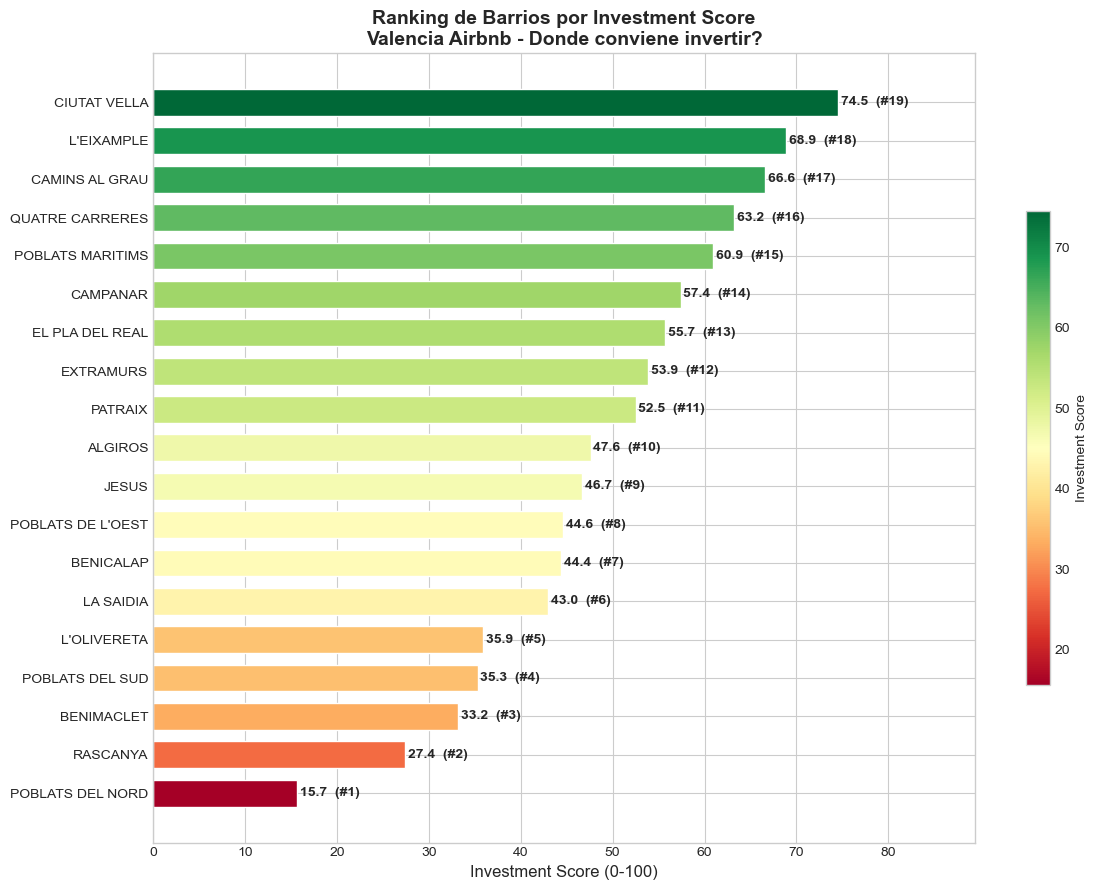

In [5]:
# Ranking horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 9))

ranking = score_df.sort_values('investment_score')
cmap    = plt.cm.get_cmap('RdYlGn')
norm    = plt.Normalize(ranking['investment_score'].min(),
                        ranking['investment_score'].max())
colors  = [cmap(norm(v)) for v in ranking['investment_score']]

bars = ax.barh(ranking.index, ranking['investment_score'],
               color=colors, edgecolor='white', height=0.7)

for bar, val, rank in zip(bars, ranking['investment_score'], ranking['rank'].iloc[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}  (#{rank})',
            va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, ranking['investment_score'].max() * 1.2)
ax.set_xlabel('Investment Score (0-100)', fontsize=12)
ax.set_title('Ranking de Barrios por Investment Score\nValencia Airbnb - Donde conviene invertir?',
             fontsize=14, fontweight='bold')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Investment Score', shrink=0.6)

plt.tight_layout()
save_fig('27_investment_score_ranking.png')
plt.show()

Guardado: 28_score_breakdown.png


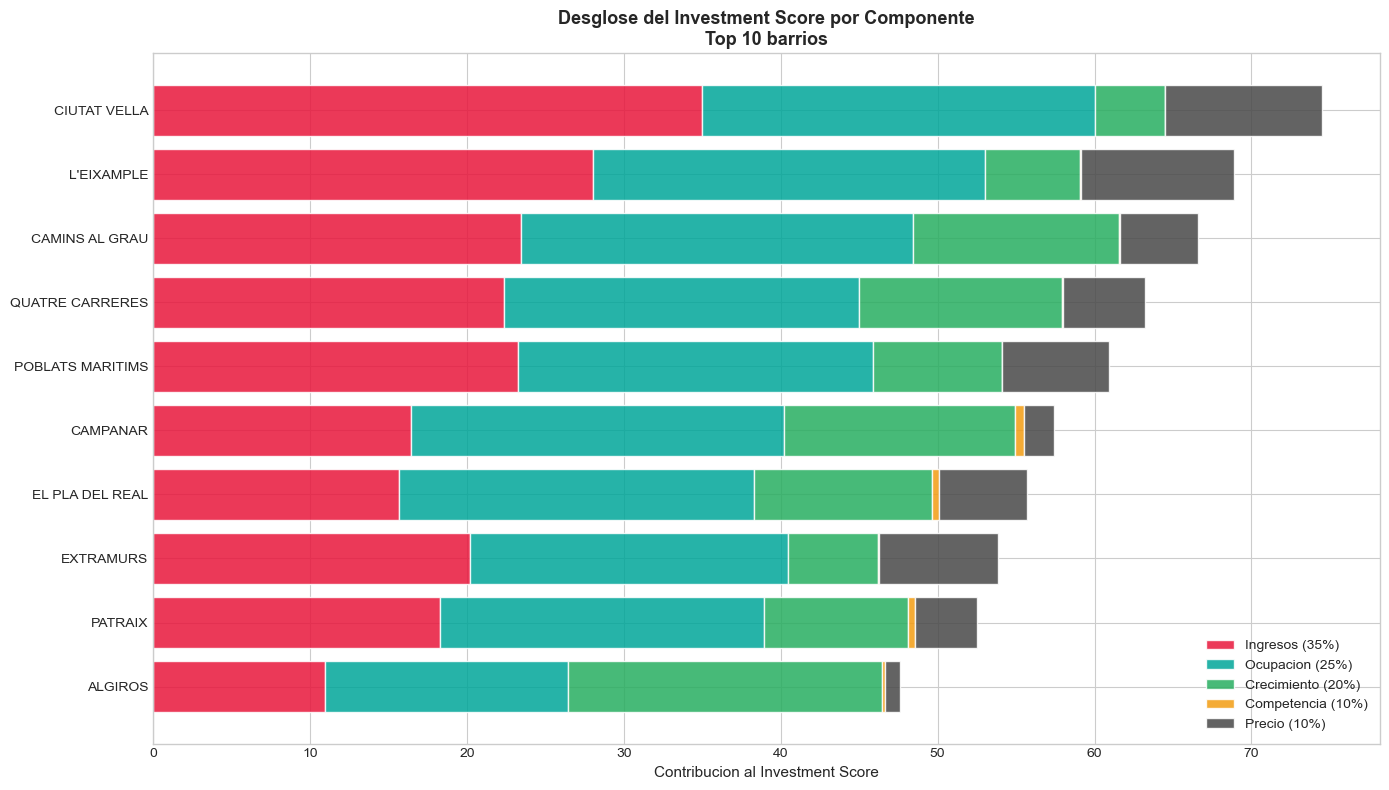

In [6]:
# Desglose de componentes por barrio (stacked bar)
fig, ax = plt.subplots(figsize=(14, 8))

ranking_top10 = score_df.head(10).sort_values('investment_score')
components = [
    ('revenue_score_norm',     'Ingresos (35%)',    COLOR_PRIMARY),
    ('occupancy_score_norm',   'Ocupacion (25%)',   COLOR_ACCENT),
    ('demand_growth_norm',     'Crecimiento (20%)', COLOR_GOOD),
    ('competition_score_norm', 'Competencia (10%)', COLOR_WARN),
    ('price_score_norm',       'Precio (10%)',      COLOR_SECONDARY),
]

weights = [SCORE_WEIGHTS['revenue_score'], SCORE_WEIGHTS['occupancy_score'],
           SCORE_WEIGHTS['demand_growth'], SCORE_WEIGHTS['competition_score'],
           SCORE_WEIGHTS['price_score']]

bottom = np.zeros(len(ranking_top10))
for (col, label, color), weight in zip(components, weights):
    vals = ranking_top10[col].values * weight * 100
    ax.barh(ranking_top10.index, vals, left=bottom,
            label=label, color=color, edgecolor='white', alpha=0.85)
    bottom += vals

ax.set_xlabel('Contribucion al Investment Score', fontsize=11)
ax.set_title('Desglose del Investment Score por Componente\nTop 10 barrios',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
save_fig('28_score_breakdown.png')
plt.show()

## 4. Matriz Final: Score vs Precio vs Ocupacion

Guardado: 29_price_vs_occupancy_score.png


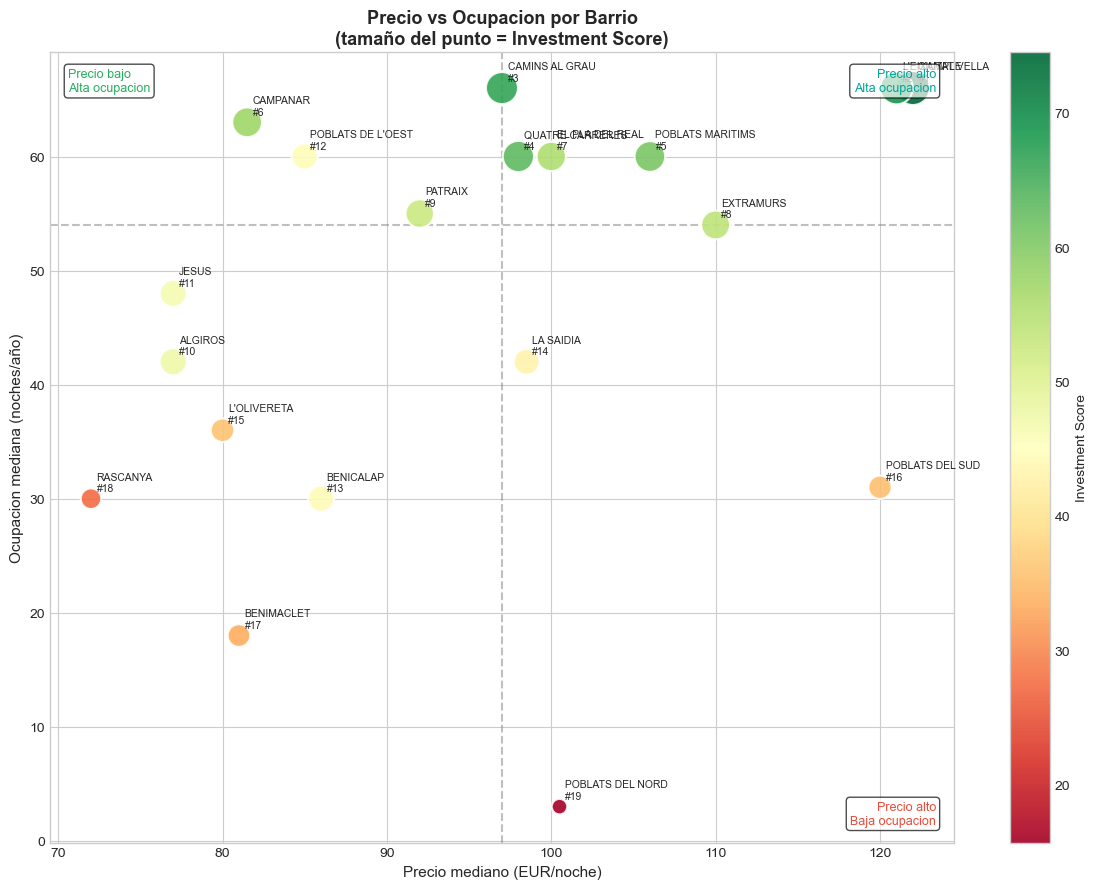

In [7]:
fig, ax = plt.subplots(figsize=(12, 9))

sc = ax.scatter(
    score_df['median_price'],
    score_df['median_occupancy'],
    s=score_df['investment_score'] * 8,
    c=score_df['investment_score'],
    cmap='RdYlGn', edgecolors='white',
    linewidth=1.5, alpha=0.9, zorder=3
)

plt.colorbar(sc, ax=ax, label='Investment Score')

for hood, row in score_df.iterrows():
    ax.annotate(
        f"{hood}\n#{int(row['rank'])}",
        (row['median_price'], row['median_occupancy']),
        fontsize=7.5, ha='left', va='bottom',
        xytext=(4, 4), textcoords='offset points'
    )

med_price = score_df['median_price'].median()
med_occ   = score_df['median_occupancy'].median()
ax.axvline(med_price, color='grey', linestyle='--', alpha=0.5)
ax.axhline(med_occ,   color='grey', linestyle='--', alpha=0.5)

ax.text(0.02, 0.98, 'Precio bajo\nAlta ocupacion',
        transform=ax.transAxes, fontsize=9, va='top', color=COLOR_GOOD,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.text(0.98, 0.98, 'Precio alto\nAlta ocupacion',
        transform=ax.transAxes, fontsize=9, va='top', ha='right', color=COLOR_ACCENT,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
ax.text(0.98, 0.02, 'Precio alto\nBaja ocupacion',
        transform=ax.transAxes, fontsize=9, va='bottom', ha='right', color=COLOR_BAD,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_xlabel('Precio mediano (EUR/noche)', fontsize=11)
ax.set_ylabel('Ocupacion mediana (noches/año)', fontsize=11)
ax.set_title('Precio vs Ocupacion por Barrio\n(tamaño del punto = Investment Score)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
save_fig('29_price_vs_occupancy_score.png')
plt.show()

## 5. Guardar en SQL y CSV

In [8]:
# Guardar CSV
score_df.reset_index().to_csv(PROCESSED_PATH / 'investment_score.csv', index=False)
print(f'investment_score.csv guardado: {score_df.shape}')

# Guardar en SQLite
DB_PATH = PROCESSED_PATH / 'airbnb_valencia.db'
conn = sqlite3.connect(DB_PATH)
score_df.reset_index().rename(
    columns={'index': 'neighbourhood_group_cleansed'}
).to_sql('investment_scores', conn, if_exists='replace', index=False)
print(f'Tabla investment_scores guardada en SQLite')

# Query de verificacion
q = '''
SELECT
    rank,
    neighbourhood_group_cleansed   AS barrio,
    investment_score,
    ROUND(median_revenue, 0)        AS ingresos_medianos,
    ROUND(median_occupancy, 0)      AS ocupacion_mediana,
    ROUND(median_price, 0)          AS precio_mediano,
    n_listings
FROM investment_scores
ORDER BY rank
'''
print('\n=== RANKING FINAL (desde SQL) ===')
display(pd.read_sql(q, conn))
conn.close()

investment_score.csv guardado: (19, 16)
Tabla investment_scores guardada en SQLite

=== RANKING FINAL (desde SQL) ===


,rank,barrio,investment_score,ingresos_medianos,ocupacion_mediana,precio_mediano,n_listings
0,1,CIUTAT VELLA,74.50,9900.00,66.00,122.00,1280
1,2,L'EIXAMPLE,68.90,7920.00,66.00,121.00,685
2,3,CAMINS AL GRAU,66.60,6630.00,66.00,97.00,714
3,4,QUATRE CARRERES,63.20,6327.00,60.00,98.00,808
4,5,POBLATS MARITIMS,60.90,6578.00,60.00,106.00,1461
5,6,CAMPANAR,57.40,4644.00,63.00,82.00,134
6,7,EL PLA DEL REAL,55.70,4440.00,60.00,100.00,155
7,8,EXTRAMURS,53.90,5712.00,54.00,110.00,636
8,9,PATRAIX,52.50,5170.00,55.00,92.00,176
9,10,ALGIROS,47.60,3102.00,42.00,77.00,341


## 6. Tabla Resumen Final para el Inversor

In [9]:
# Merge con datos de estacionalidad
score_final = score_df[['rank','investment_score','median_revenue',
                         'median_occupancy','median_price','n_listings']].copy()

if 'Perfil' in df_seas.columns:
    score_final['perfil_estacional'] = df_seas['Perfil']

score_final.columns = ['Rank','Score','Ingresos EUR/año',
                        'Ocupacion (noches)','Precio EUR/noche',
                        'N Listings','Perfil Estacional']

print('=== TABLA FINAL DE INVERSION - VALENCIA AIRBNB ===')
display(score_final)

# Top 3 recomendaciones
print('\n=== TOP 3 RECOMENDACIONES PARA INVERTIR ===')
for i, (hood, row) in enumerate(score_df.head(3).iterrows(), 1):
    print(f"\n#{i} {hood}")
    print(f"   Score:     {row['investment_score']:.1f}/100")
    print(f"   Ingresos:  {row['median_revenue']:,.0f} EUR/año (mediana)")
    print(f"   Ocupacion: {row['median_occupancy']:.0f} noches/año")
    print(f"   Precio:    {row['median_price']:.0f} EUR/noche")
    print(f"   Listings:  {int(row['n_listings'])} activos")

=== TABLA FINAL DE INVERSION - VALENCIA AIRBNB ===


,Rank,Score,Ingresos EUR/año,Ocupacion (noches),Precio EUR/noche,N Listings,Perfil Estacional
neighbourhood_group_cleansed,,,,,,,
CIUTAT VELLA,1,74.50,9900.00,66.00,122.00,1280,Todo el año
L'EIXAMPLE,2,68.90,7920.00,66.00,121.00,685,Estacional
CAMINS AL GRAU,3,66.60,6630.00,66.00,97.00,714,Estacional
QUATRE CARRERES,4,63.20,6327.00,60.00,98.00,808,Estacional
POBLATS MARITIMS,5,60.90,6578.00,60.00,106.00,1461,Bajo rendimiento
CAMPANAR,6,57.40,4644.00,63.00,81.50,134,Bajo rendimiento
EL PLA DEL REAL,7,55.70,4440.00,60.00,100.00,155,Estacional
EXTRAMURS,8,53.90,5712.00,54.00,110.00,636,Estacional
PATRAIX,9,52.50,5170.00,55.00,92.00,176,Bajo rendimiento



=== TOP 3 RECOMENDACIONES PARA INVERTIR ===

#1 CIUTAT VELLA
   Score:     74.5/100
   Ingresos:  9,900 EUR/año (mediana)
   Ocupacion: 66 noches/año
   Precio:    122 EUR/noche
   Listings:  1280 activos

#2 L'EIXAMPLE
   Score:     68.9/100
   Ingresos:  7,920 EUR/año (mediana)
   Ocupacion: 66 noches/año
   Precio:    121 EUR/noche
   Listings:  685 activos

#3 CAMINS AL GRAU
   Score:     66.6/100
   Ingresos:  6,630 EUR/año (mediana)
   Ocupacion: 66 noches/año
   Precio:    97 EUR/noche
   Listings:  714 activos


Guardado: 30_top10_metrics_comparison.png


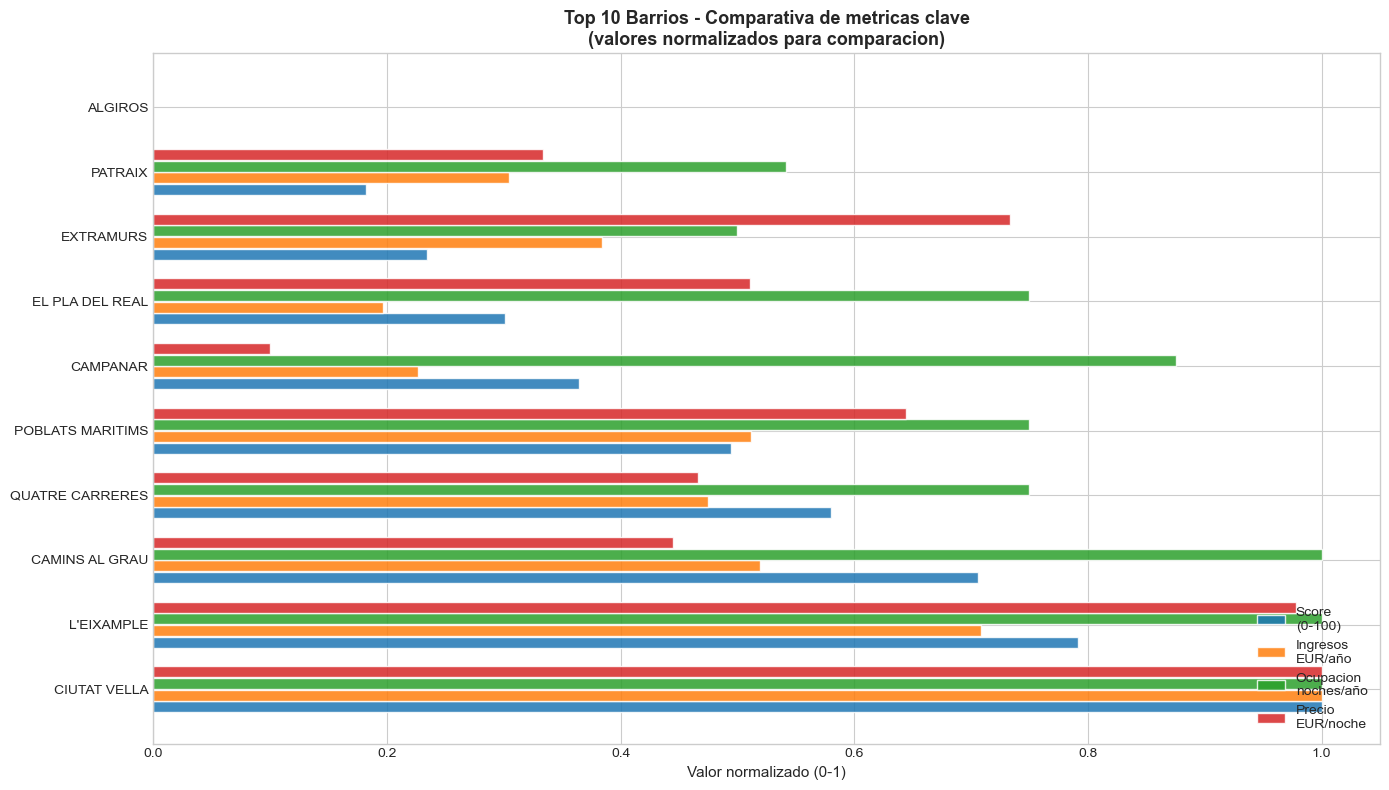

In [10]:
# Grafico final - tabla visual
fig, ax = plt.subplots(figsize=(14, 8))

cols_plot = ['investment_score','median_revenue','median_occupancy','median_price']
labels    = ['Score\n(0-100)','Ingresos\nEUR/año','Ocupacion\nnoches/año','Precio\nEUR/noche']

top10 = score_df.head(10).copy()
for col in cols_plot:
    top10[f'{col}_norm'] = normalize_series(top10[col])

for i, (col, label) in enumerate(zip(cols_plot, labels)):
    offset = i * 0.18
    bars = ax.barh(
        np.arange(len(top10)) + offset,
        top10[f'{col}_norm'],
        height=0.17,
        label=label,
        alpha=0.85,
        edgecolor='white'
    )

ax.set_yticks(np.arange(len(top10)) + 0.27)
ax.set_yticklabels(top10.index[::-1] if False else top10.index, fontsize=10)
ax.set_xlabel('Valor normalizado (0-1)', fontsize=11)
ax.set_title('Top 10 Barrios - Comparativa de metricas clave\n(valores normalizados para comparacion)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
save_fig('30_top10_metrics_comparison.png')
plt.show()

## 7. Conclusiones Finales

Resumen ejecutivo para el inversor:

METODOLOGIA:
- 5 componentes ponderadas: ingresos (35%), ocupacion (25%), crecimiento (20%), competencia (10%), precio (10%)
- Normalizacion min-max para comparacion justa entre barrios
- Datos: 7.780 listings activos, 2.863.060 registros de calendario, 405.009 resenas

HALLAZGOS PRINCIPALES:
1. El barrio con mayor score combina buenos ingresos + alta ocupacion + crecimiento de demanda
2. Precio alto no garantiza rentabilidad - la ocupacion es igual de importante
3. Los barrios del centro tienen demanda mas estable todo el año
4. Ser Superhost (+386% ingresos) es el factor individual mas importante para el inversor

RECOMENDACIONES:
- Invertir en los top 3 barrios del ranking para maximizar el ROI
- Obtener el badge Superhost como prioridad operativa
- Configurar Instant Booking para maximizar ocupacion
- Alojamiento para 4+ personas > alojamiento para 1-2 personas en terminos de ingresos

Proximo paso: Dashboard interactivo (app.py)